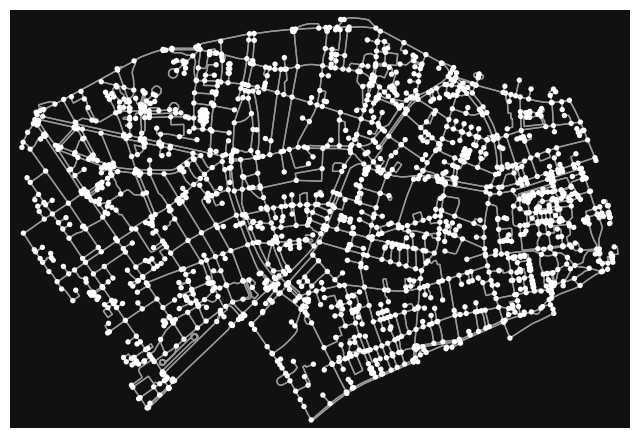

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [216]:
import osmnx as ox

# Name des Stadtteils als Suchbegriff
place = "Barmbek-Süd, Hamburg, Germany"

# Straßennetz laden (z.B. für Fußgänger)
G = ox.graph_from_place(place, network_type='walk')

# Karte anzeigen
ox.plot_graph(G)

In [217]:
import networkx as nx

# Alle Knoten
nodes = G.nodes()

# Kreuzungen: Knoten mit mind. 3 Verbindungen
intersections = [node for node, degree in dict(G.degree()).items() if degree >= 3]

# Fläche Barmbek-Süd (z.B. 2.65 km²)
area_km2 = 2.65

# Kreuzungsdichte
intersection_density = len(intersections) / area_km2
print(f"Intersection density: {intersection_density:.2f} intersections/km²")

Intersection density: 498.11 intersections/km²


In [206]:
barriers = edges[edges['barrier'].notnull()]
print(f"Number of barrier edges: {len(barriers)}")

KeyError: 'barrier'

In [218]:
import osmnx as ox

place = "Barmbek-Süd, Hamburg, Germany"
G = ox.graph_from_place(place, network_type='walk')

# Graph in GeoDataFrame umwandeln
edges = ox.graph_to_gdfs(G, nodes=False)

# vorhandene Spalten anzeigen
print(edges.columns)

Index(['osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed',
       'length', 'geometry', 'ref', 'service', 'access', 'width', 'tunnel',
       'bridge'],
      dtype='object')


In [208]:
import pandas as pd


# 'width' in numerische Werte umwandeln, Fehler in NaN konvertieren
edges['width_num'] = pd.to_numeric(edges['width'], errors='coerce')

# Fußgängerbarrieren erkennen (approximativ)
# private/no access oder sehr schmale Wege (<1 m)
potential_barriers = edges[
    (edges['access'].isin(['private', 'no'])) |
    (edges['width_num'] < 1.0)
]

print(f"Number of potential barrier edges: {len(potential_barriers)}")

Number of potential barrier edges: 0


In [209]:
potential_barriers = edges[
    (edges['access'].isin(['private', 'no'])) |
    (edges['width_num'] < 1.0)
]

print(f"Number of potential barrier edges: {len(potential_barriers)}")

Number of potential barrier edges: 0


In [210]:
potential_barriers = edges[edges['access'].isin(['private', 'no'])]
print(len(potential_barriers))

0


In [211]:
# für das gesamte straßenpaket..besser overpass

import overpy

api = overpy.Overpass()

# Overpass-Abfrage
query = """
area["name"="Barmbek-Süd"]["boundary"="administrative"]->.searchArea;
(
  way["footway"]["foot"="blind"](area.searchArea);
  way["footway"]["tactile_paving"](area.searchArea);
);
out body;
>;
out skel qt;
"""

result = api.query(query)

# Alle Wege ausgeben
for way in result.ways:
    print(way.id, way.tags)

In [212]:
import overpy

# API mit Mirror
api = overpy.Overpass(url="https://overpass.kumi.systems/api/interpreter")

# Bounding Box um Hamburger Straße U3 Haltestelle + Blinden-Zentrum
# [Süd, West, Nord, Ost] – in Grad
bbox = [53.5905, 10.0135, 53.5925, 10.0165]

# Optimierte Abfrage: nur Fußwege, die für Blinde relevant sein könnten
query = f"""
(
  way["highway"="footway"]["sidewalk"]( {bbox[0]}, {bbox[1]}, {bbox[2]}, {bbox[3]} );
  way["footway"="blinds"]( {bbox[0]}, {bbox[1]}, {bbox[2]}, {bbox[3]} );
);
out geom;
"""

# Query absetzen
result = api.query(query)

# Ergebnisse prüfen
print(f"Number of footways found: {len(result.ways)}")

for way in result.ways:
    print(f"Way ID: {way.id}, Tags: {way.tags}")

Number of footways found: 0


In [213]:
import geopandas as gpd

# GeoJSON laden
gdf = gpd.read_file("blindenzentrum_footways.geojson")

# Überblick verschaffen
print(gdf.head())
print(gdf.columns)
print(f"Number of features: {len(gdf)}")

# Nur Blindenwege filtern (falls als 'footway' markiert)
if 'footway' in gdf.columns:
    blind_footways = gdf[gdf['footway'] == 'blinds']
    print(f"Number of blind footways: {len(blind_footways)}")
else:
    print("No 'footway' column found, check 'tags' or properties in GeoJSON.")

# Optional: Karte anzeigen
blind_footways.plot(figsize=(10, 10), color='red')

DataSourceError: blindenzentrum_footways.geojson: No such file or directory

In [ ]:
import json

with open("../data/raw/blindenzentrum_footways.geojson") as f:
    data = json.load(f)

print(data.keys())  # Sollte 'type', 'features' enthalten
print(len(data['features']))  # Anzahl der Features
if len(data['features']) > 0:
    print(data['features'][0])

dict_keys(['type', 'generator', 'copyright', 'timestamp', 'features'])
33
{'type': 'Feature', 'properties': {'@id': 'way/332053541', 'footway': 'sidewalk', 'highway': 'footway', 'lit': 'yes', 'surface': 'paving_stones'}, 'geometry': {'type': 'LineString', 'coordinates': [[10.0214984, 53.5803175], [10.0213578, 53.5803443], [10.0212384, 53.5803672], [10.0214011, 53.5802146]]}, 'id': 'way/332053541'}


In [ ]:
len(data['features'])

33

In [ ]:
import geopandas as gpd

gdf = gpd.read_file("../data/raw/blindenzentrum_footways.geojson")

print(gdf.head())
print(gdf.columns)
print(len(gdf))

              id            @id bicycle check_date:bicycle covered   footway  \
0  way/332053541  way/332053541    None                NaT    None  sidewalk   
1  way/371376386  way/371376386    None                NaT    None  sidewalk   
2  way/371435901  way/371435901    None                NaT    None  sidewalk   
3  way/605698878  way/605698878      no                NaT    None  sidewalk   
4  way/610012653  way/610012653      no                NaT    None  sidewalk   

   highway incline is_sidepath:of is_sidepath:of:name layer  lit  smoothness  \
0  footway    None           None                None  None  yes        None   
1  footway    None           None                None  None  yes        good   
2  footway    None           None                None  None  yes        None   
3  footway    None           None                None  None  yes        None   
4  footway    None           None                None  None   no  impassable   

           surface                    

In [ ]:
gdf.describe(include='all')

,id,@id,bicycle,check_date:bicycle,covered,footway,highway,incline,is_sidepath:of,is_sidepath:of:name,layer,lit,smoothness,surface,geometry
count,33,33,2,1,3,33,33,1,2,2,3,28,9,33,33
unique,33,33,1,NaN,1,1,1,1,1,1,1,2,4,4,33
top,way/332053541,way/332053541,no,NaN,yes,sidewalk,footway,down,primary,Oberaltenallee,-1,yes,good,paving_stones,"LINESTRING (10.0214984 53.5803175, 10.0213578 ..."
freq,1,1,2,NaN,3,33,33,1,2,2,3,27,3,30,1
mean,NaN,NaN,NaN,2024-08-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,2024-08-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2024-08-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2024-08-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2024-08-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,2024-08-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
for col in ['footway', 'lit', 'smoothness', 'surface']:
    print(f"\n{col}:")
    print(gdf[col].value_counts(dropna=False))


footway:


NameError: name 'gdf' is not defined

In [1]:
# ALLES NUN IN MESSBARE DATEN: 1. Beleuchtung (Safety / Walkability)
gdf['is_lit'] = gdf['lit'] == 'yes'

NameError: name 'gdf' is not defined

In [201]:
#2. Gute Wegqualität
good_surface = ['paving_stones', 'asphalt', 'concrete']

gdf['good_surface'] = gdf['surface'].isin(good_surface)

KeyError: 'surface'

In [ ]:
#3. Barrieren / schlechte Wege
gdf['is_bad'] = gdf['smoothness'].isin(['bad', 'very_bad', 'impassable'])

In [203]:
#4. Sidewalk vorhanden
gdf['has_sidewalk'] = gdf['footway'] == 'sidewalk'


KeyError: 'footway'

In [202]:
#Metriken bauen
total = len(gdf)

print("Lighting:", gdf['is_lit'].mean())
print("Good surface:", gdf['good_surface'].mean())
print("Bad paths:", gdf['is_bad'].mean())
print("Sidewalk share:", gdf['has_sidewalk'].mean())

KeyError: 'is_lit'

In [ ]:
#Walkability Score

gdf['score'] = (
    gdf['is_lit'] * 1 +
    gdf['good_surface'] * 1 +
    gdf['has_sidewalk'] * 1 -
    gdf['is_bad'] * 2
)

walkability_score = gdf['score'].mean()

print("Walkability Score:", walkability_score)



Walkability Score: 2.515151515151515


<Axes: >

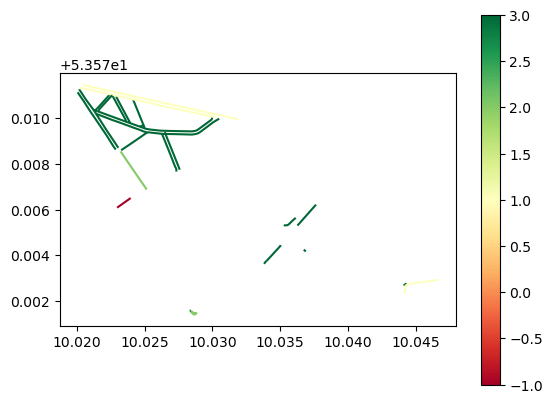

In [ ]:
gdf.plot(column='score', cmap='RdYlGn', legend=True)

In [3]:
import os
import pandas as pd

# Pfad zu deinen Geoportal CSV-Dateien
data_path = "../data/raw/raw_data_geoportal/"

# Dictionary für alle DataFrames
dfs = {}

# Alle CSV-Dateien im Ordner einlesen
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        df_name = file.replace(".csv", "")
        try:
            dfs[df_name] = pd.read_csv(
                os.path.join(data_path, file),
                sep=";",              # Geoportal CSVs haben oft ; als Trenner
                encoding="utf-8",      # oder "latin1", falls utf-8 Fehler gibt
                low_memory=False,
                on_bad_lines="skip"    # kaputte Zeilen überspringen
            )
            print(f"Loaded '{df_name}' with shape {dfs[df_name].shape}")
        except Exception as e:
            print(f"Failed to load '{df_name}': {e}")

print(f"\nTotal datasets loaded: {len(dfs)}")
print("Available datasets:", list(dfs.keys()))

Loaded 'de_hh_up_nsz_area_EPSG_4326' with shape (1, 30)
Loaded 'de_hh_up_ruhige_gebiete_hamburg_EPSG_4326' with shape (15, 5)
Loaded 'de_hh_up_busfahrstreifen_EPSG_4326' with shape (412, 17)
Loaded 'de_hh_up_bundesstrassen_ortsdurchfahrt_EPSG_4326' with shape (499, 25)
Loaded 'de_hh_up_baustelle_EPSG_4326' with shape (133, 30)
Loaded 'app_stromnetz_emobility_EPSG_4326' with shape (3008, 14)
Loaded 'de_hh_up_mrh_ik_bewaesserungsanlagen_EPSG_4326' with shape (3, 13)
Loaded 'de_hh_up_strassendeckschicht_EPSG_4326' with shape (37845, 25)
Loaded 'de_hh_up_fussgaengerueberwege_EPSG_4326' with shape (1254, 11)
Loaded 'de_hh_up_bewohnerparkgebiete_EPSG_4326' with shape (145, 15)
Loaded 'de_hh_up_switch_punkte_api_EPSG_4326' with shape (220, 15)
Loaded 'de_hh_up_autobahnen_EPSG_4326' with shape (1514, 3)
Loaded 'de_hh_up_stadtrad_stationen_EPSG_4326' with shape (334, 14)
Loaded 'de_hh_up_modalsplit_stadtregion_EPSG_4326' with shape (7, 9)
Loaded 'de_hh_up_behindertenstellplaetze_EPSG_4326' with

In [4]:
df_footways = dfs['de_hh_up_fussgaengerueberwege_EPSG_4326']
print(df_footways.head())
print(df_footways.columns)

                                   _fid  vz_nr       bezeichnung  \
0  DE.HH.UP_FUSSGAENGERUEBERWEGE_200012    293  Fußgängerüberweg   
1  DE.HH.UP_FUSSGAENGERUEBERWEGE_200013    293  Fußgängerüberweg   
2  DE.HH.UP_FUSSGAENGERUEBERWEGE_200014    293  Fußgängerüberweg   
3  DE.HH.UP_FUSSGAENGERUEBERWEGE_200015    293  Fußgängerüberweg   
4  DE.HH.UP_FUSSGAENGERUEBERWEGE_200016    293  Fußgängerüberweg   

  strassenschluessel              strassenname              koordinaten  \
0               C029  Christian-Förster-Straße  563803.871, 5937552.319   
1               W249              Wiesingerweg    563637.82, 5937606.37   
2               T198          Troplowitzstraße  564103.543, 5937892.346   
3               B103                 Baumacker  559383.483, 5941156.007   
4               M032            Mansteinstraße  564184.243, 5936861.561   

       quelle erfassungsdatum  bemerkung                        geom  \
0  CycloMedia      2023-10-23        NaN  POINT (9.963775 53.582935)

In [5]:
df_footways = dfs['de_hh_up_fussgaengerueberwege_EPSG_4326']
print(df_footways.head())
print(df_footways.columns)

                                   _fid  vz_nr       bezeichnung  \
0  DE.HH.UP_FUSSGAENGERUEBERWEGE_200012    293  Fußgängerüberweg   
1  DE.HH.UP_FUSSGAENGERUEBERWEGE_200013    293  Fußgängerüberweg   
2  DE.HH.UP_FUSSGAENGERUEBERWEGE_200014    293  Fußgängerüberweg   
3  DE.HH.UP_FUSSGAENGERUEBERWEGE_200015    293  Fußgängerüberweg   
4  DE.HH.UP_FUSSGAENGERUEBERWEGE_200016    293  Fußgängerüberweg   

  strassenschluessel              strassenname              koordinaten  \
0               C029  Christian-Förster-Straße  563803.871, 5937552.319   
1               W249              Wiesingerweg    563637.82, 5937606.37   
2               T198          Troplowitzstraße  564103.543, 5937892.346   
3               B103                 Baumacker  559383.483, 5941156.007   
4               M032            Mansteinstraße  564184.243, 5936861.561   

       quelle erfassungsdatum  bemerkung                        geom  \
0  CycloMedia      2023-10-23        NaN  POINT (9.963775 53.582935)

In [6]:
import geopandas as gpd
from shapely import wkt

# Annahme: df_footways ist dein DataFrame aus 'de_hh_up_fussgaengerueberwege_EPSG_4326'
df_footways['geometry'] = df_footways['geom'].apply(wkt.loads)

gdf_footways = gpd.GeoDataFrame(df_footways, geometry='geometry', crs="EPSG:4326")
print(gdf_footways.head())

                                   _fid  vz_nr       bezeichnung  \
0  DE.HH.UP_FUSSGAENGERUEBERWEGE_200012    293  Fußgängerüberweg   
1  DE.HH.UP_FUSSGAENGERUEBERWEGE_200013    293  Fußgängerüberweg   
2  DE.HH.UP_FUSSGAENGERUEBERWEGE_200014    293  Fußgängerüberweg   
3  DE.HH.UP_FUSSGAENGERUEBERWEGE_200015    293  Fußgängerüberweg   
4  DE.HH.UP_FUSSGAENGERUEBERWEGE_200016    293  Fußgängerüberweg   

  strassenschluessel              strassenname              koordinaten  \
0               C029  Christian-Förster-Straße  563803.871, 5937552.319   
1               W249              Wiesingerweg    563637.82, 5937606.37   
2               T198          Troplowitzstraße  564103.543, 5937892.346   
3               B103                 Baumacker  559383.483, 5941156.007   
4               M032            Mansteinstraße  564184.243, 5936861.561   

       quelle erfassungsdatum  bemerkung                        geom  \
0  CycloMedia      2023-10-23        NaN  POINT (9.963775 53.582935)

In [ ]:
# Beispiel: nur Fußgängerüberwege auf der "Christian-Förster-Straße"
gdf_cf = gdf_footways[gdf_footways['strassenname'] == "Christian-Förster-Straße"]

# Nur die Punkte aus CycloMedia
gdf_cyclo = gdf_footways[gdf_footways['quelle'] == "CycloMedia"]

In [ ]:
gdf_footways.to_file("../data/processed/footways.geojson", driver="GeoJSON")

In [7]:
data_path = "../data/raw/raw_data_geoportal/"

df_bewohnerpark = pd.read_csv(
    os.path.join(data_path, "de_hh_up_bewohnerparkgebiete_EPSG_4326.csv"),
    engine='python',
    on_bad_lines='skip',
    sep=';'
)

In [8]:
df_baustelle = pd.read_csv(
    os.path.join(data_path, "de_hh_up_baustelle_EPSG_4326.csv"),
    engine='python',
    on_bad_lines='skip',
    sep=';'
)

In [9]:
df_bewohnerpark.head()

,_fid,objectid,bwp_name,bwp_code,geplant_aktiv,sonderbewirtschaftung,bemerkung,bewirtschaftungsart,bewirtschaftungszeit,hoechstparkdauer,gebuehrenzone,parkstaende,hinweis_intern,geom,coordinate_reference_system
0,DE.HH.UP_BEWOHNERPARKGEBIETE_28481,1,N 101 Flughafenstraße,N101,2,0,Stand 2019,"Parkscheibe, Bewohner mit Ausweis frei",täglich 9-20 Uhr,180,Parkscheibe,NaN,NaN,"MULTIPOLYGON (((10.014561 53.643272,10.015903 ...",EPSG:4326
1,DE.HH.UP_BEWOHNERPARKGEBIETE_28482,2,N 100 Flughafen,N100,2,0,Stand 2006,"Parkscheibe, Bewohner mit Ausweis frei",täglich 9-20 Uhr,180,Parkscheibe,NaN,NaN,"MULTIPOLYGON (((10.013491 53.637756,10.013632 ...",EPSG:4326
2,DE.HH.UP_BEWOHNERPARKGEBIETE_28483,3,N 103 Etzestraße,N103,2,0,Stand 2019,"Parkscheibe, Bewohner mit Ausweis frei",täglich 9-20 Uhr,180,Parkscheibe,NaN,NaN,"MULTIPOLYGON (((10.015948 53.634462,10.016282 ...",EPSG:4326
3,DE.HH.UP_BEWOHNERPARKGEBIETE_28484,4,N 102 Bergkoppelweg,N102,2,0,Stand 2019,"Parkscheibe, Bewohner mit Ausweis frei",täglich 9-20 Uhr,180,Parkscheibe,NaN,NaN,"MULTIPOLYGON (((10.024171 53.634657,10.024481 ...",EPSG:4326
4,DE.HH.UP_BEWOHNERPARKGEBIETE_28485,5,N 105 Ohlendörp,N105,2,0,Stand 2019,"Parkscheibe, Bewohner mit Ausweis frei",täglich 9-20 Uhr,180,Parkscheibe,NaN,NaN,"MULTIPOLYGON (((10.014063 53.627541,10.013994 ...",EPSG:4326


In [10]:
df_baustelle.head()

,_fid,gml_identifier,gml_identifier_attr_codespace,titel,organisation,anlass,umfang,baubeginn,bauende,letzteaktualisierung,...,oevnveinschraenkungen,hatinternetlink,internetlink,hatumleitungsbeschreibung,umleitungsbeschreibung,istparkraumeingeschraenkt,parkraumeinschraenkung,einsatzkraefte,tns_koordinate_value,coordinate_reference_system
0,DE.HH.UP_BAUSTELLE_19195,NaN,NaN,Brücken-Straßen für Tunnel Altona,Autobahn GmbH,Bau des Deckels / Tunnels Altona,Brücken-Straßen:Bahrenfelder Chausseebis 14.07...,02.03.2020,31.12.2028,2021-08-20T15:09:33,...,NaN,True,https://www.deges.de/projekte/projekt/a-7-alto...,False,NaN,False,NaN,NaN,POINT (9.898762 53.562577),EPSG:4326
1,DE.HH.UP_BAUSTELLE_952837,NaN,NaN,Radwegbrücke Bw.-Nr. 1484 Brombeerweg,LSBG,Die Radwegbrücke Brombeerweg soll parallel zur...,Das Baufeld beinhaltet den Überbau der Brücke ...,27.12.2027,22.12.2028,2024-08-21T14:28:24,...,NaN,False,NaN,False,NaN,True,Im Rahmen der Maßnahme kann es im Straßenberei...,NaN,POINT (10.029990 53.630944),EPSG:4326
2,DE.HH.UP_BAUSTELLE_861962,NaN,NaN,"Reiherstiegschleuse / Erneuerung Schleuse, Brü...",Hamburg Port Authority,Neubau der Reiherstiegschleuse und Brücke,"Hohe Schaar-Straße 36-44, 21107 Hamburgca. 450...",20.06.2024,31.12.2027,2025-03-28T12:54:45,...,Bushaltestelle „Hohe-Schaar“ Richtung Kornweid...,False,NaN,False,NaN,False,NaN,NaN,POINT (9.983625 53.480242),EPSG:4326
3,DE.HH.UP_BAUSTELLE_36075,NaN,NaN,Moorburger Elbdeich / Brückenneubau,DEGES,Vorbereitung für die Erweiterung der A 7 und d...,"bis 23.04.2022: Vollsperrung nachts, tagsüber ...",01.04.2022,06.11.2030,2022-04-13T07:13:27,...,NaN,False,NaN,False,NaN,False,NaN,NaN,POINT (9.913674 53.495455),EPSG:4326
4,DE.HH.UP_BAUSTELLE_791202,NaN,NaN,Stresemannstraße / Max-Brauer-Allee - Eisenbah...,Deutsche Bahn / Bauwerke,Die Eisenbahnüberführung (EÜ) „Sternbrücke“ au...,aktuelle Informationen zur Verkehrsführung fin...,24.07.2023,11.03.2027,2024-05-06T12:45:24,...,NaN,True,https://www.eisenbahnbruecken-ehm.de/sternbrue...,False,NaN,False,NaN,NaN,POINT (9.954986 53.561304),EPSG:4326


In [11]:
import geopandas as gpd
from shapely import wkt
import pandas as pd
import os

# Pfad zu deinen CSVs
data_path = "../data/raw/raw_data_geoportal/"

# CSV laden
df_bewohnerpark = pd.read_csv(
    os.path.join(data_path, "de_hh_up_bewohnerparkgebiete_EPSG_4326.csv"),
    engine='python',
    on_bad_lines='skip',
    sep=';'
)

# 'geom' Spalte von WKT in GeoDataFrame umwandeln
df_bewohnerpark['geometry'] = df_bewohnerpark['geom'].apply(wkt.loads)
gdf_bewohnerpark = gpd.GeoDataFrame(df_bewohnerpark, geometry='geometry', crs="EPSG:4326")

# Optional: Überprüfung
print(gdf_bewohnerpark.head())
print(gdf_bewohnerpark.crs)

                                 _fid  objectid               bwp_name  \
0  DE.HH.UP_BEWOHNERPARKGEBIETE_28481         1  N 101 Flughafenstraße   
1  DE.HH.UP_BEWOHNERPARKGEBIETE_28482         2       N 100 Flughafen    
2  DE.HH.UP_BEWOHNERPARKGEBIETE_28483         3       N 103 Etzestraße   
3  DE.HH.UP_BEWOHNERPARKGEBIETE_28484         4    N 102 Bergkoppelweg   
4  DE.HH.UP_BEWOHNERPARKGEBIETE_28485         5        N 105 Ohlendörp   

  bwp_code  geplant_aktiv  sonderbewirtschaftung   bemerkung  \
0     N101              2                      0  Stand 2019   
1     N100              2                      0  Stand 2006   
2     N103              2                      0  Stand 2019   
3     N102              2                      0  Stand 2019   
4     N105              2                      0  Stand 2019   

                      bewirtschaftungsart bewirtschaftungszeit  \
0  Parkscheibe, Bewohner mit Ausweis frei     täglich 9-20 Uhr   
1  Parkscheibe, Bewohner mit Ausweis f

In [12]:
import geopandas as gpd
from shapely import wkt

# Sicheres WKT-Parsing für df_bewohnerpark
def safe_wkt_loads(s):
    try:
        if pd.isna(s) or s.strip() == "":
            return None
        return wkt.loads(s)
    except Exception as e:
        print(f"⚠️ WKT Fehler: {s[:30]}... -> {e}")
        return None

# Geometrie-Spalte erzeugen
df_bewohnerpark['geometry'] = df_bewohnerpark['geom'].apply(safe_wkt_loads)

# Fehlende Geometrien entfernen (optional)
df_bewohnerpark = df_bewohnerpark.dropna(subset=['geometry'])

# GeoDataFrame erstellen
gdf_bewohnerpark = gpd.GeoDataFrame(df_bewohnerpark, geometry='geometry', crs="EPSG:4326")

# Optional: GeoJSON speichern
gdf_bewohnerpark.to_file("../data/processed/bewohnerpark.geojson", driver="GeoJSON")

print(f"✅ GeoDataFrame erstellt: {gdf_bewohnerpark.shape[0]} Zeilen")

✅ GeoDataFrame erstellt: 144 Zeilen


In [13]:
import geopandas as gpd
from shapely import wkt
import pandas as pd
import os

# Pfad zu deinen CSVs
data_path = "../data/raw/raw_data_geoportal/"

# --- Bewohnerparkgebiete ---
df_bewohnerpark = pd.read_csv(
    os.path.join(data_path, "de_hh_up_bewohnerparkgebiete_EPSG_4326.csv"),
    engine='python',
    on_bad_lines='skip',
    sep=';'
)
df_bewohnerpark['geometry'] = df_bewohnerpark['geom'].apply(wkt.loads)
gdf_bewohnerpark = gpd.GeoDataFrame(df_bewohnerpark, geometry='geometry', crs="EPSG:4326")

# --- Baustellen ---
df_baustelle = pd.read_csv(
    os.path.join(data_path, "de_hh_up_baustelle_EPSG_4326.csv"),
    engine='python',
    on_bad_lines='skip',
    sep=';'
)
df_baustelle['geometry'] = df_baustelle['tns_koordinate_value'].apply(wkt.loads)
gdf_baustelle = gpd.GeoDataFrame(df_baustelle, geometry='geometry', crs="EPSG:4326")

# --- Optional: beide an bestehendes gdf_all anhängen ---
gdf_all = pd.concat([gdf_all, gdf_bewohnerpark, gdf_baustelle], ignore_index=True)

# --- Überprüfung ---
print(gdf_all.shape)
print(gdf_all.crs)
print(gdf_all[['geometry']].head())

NameError: name 'gdf_all' is not defined

In [ ]:
import geopandas as gpd
from shapely import wkt

# Sicheres WKT-Parsing für df_bewohnerpark
def safe_wkt_loads(s):
    try:
        if pd.isna(s) or s.strip() == "":
            return None
        return wkt.loads(s)
    except Exception as e:
        print(f"⚠️ WKT Fehler: {s[:30]}... -> {e}")
        return None

# Geometrie-Spalte erzeugen
df_bewohnerpark['geometry'] = df_bewohnerpark['geom'].apply(safe_wkt_loads)

# Fehlende Geometrien entfernen (optional)
df_bewohnerpark = df_bewohnerpark.dropna(subset=['geometry'])

# GeoDataFrame erstellen
gdf_bewohnerpark = gpd.GeoDataFrame(df_bewohnerpark, geometry='geometry', crs="EPSG:4326")

# Optional: GeoJSON speichern
gdf_bewohnerpark.to_file("../data/processed/bewohnerpark.geojson", driver="GeoJSON")

print(f"✅ GeoDataFrame erstellt: {gdf_bewohnerpark.shape[0]} Zeilen")

✅ GeoDataFrame erstellt: 144 Zeilen


In [14]:
import os
import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point

data_path = "../data/raw/raw_data_geoportal/"

# Lade CSV- und GeoJSON-Dateien
data_files = [f for f in os.listdir(data_path) if f.endswith(".csv") or f.endswith(".geojson")]
gdfs = []

def safe_wkt_loads(s):
    try:
        if pd.isna(s) or str(s).strip() == "":
            return None
        return wkt.loads(s)
    except Exception as e:
        print(f"⚠️ WKT Fehler: {str(s)[:30]}... -> {e}")
        return None

for file in data_files:
    full_path = os.path.join(data_path, file)
    try:
        if file.endswith(".csv"):
            # CSV einlesen
            try:
                df = pd.read_csv(full_path, sep=';', engine='python')
            except pd.errors.ParserError:
                df = pd.read_csv(full_path, sep=',', engine='python')

            # Geometrie bestimmen
            if 'geom' in df.columns:
                df['geometry'] = df['geom'].apply(safe_wkt_loads)
            elif 'koordinaten' in df.columns:
                def parse_coords(s):
                    try:
                        x, y = s.split(',')
                        return Point(float(x.strip()), float(y.strip()))
                    except:
                        return None
                df['geometry'] = df['koordinaten'].apply(parse_coords)
            elif 'tns_koordinate_value' in df.columns:
                df['geometry'] = df['tns_koordinate_value'].apply(safe_wkt_loads)
            else:
                print(f"⚠️ '{file}' enthält keine Geometrie-Spalte, wird übersprungen.")
                continue

            # GeoDataFrame erzeugen
            gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

        elif file.endswith(".geojson"):
            # GeoJSON direkt laden
            gdf = gpd.read_file(full_path)
        
        # Fehlende Geometrien entfernen
        gdf = gdf.dropna(subset=['geometry'])
        gdfs.append(gdf)
        print(f"✅ Loaded '{file}' with shape {gdf.shape}")

    except Exception as e:
        print(f"⚠️ Fehler beim Laden von '{file}': {e}")

# Alle GeoDataFrames zusammenführen
if gdfs:
    gdf_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs="EPSG:4326")
    print(f"✅ Alle Datensätze zusammengeführt: {gdf_all.shape[0]} Zeilen")
    
    # GeoJSON speichern
    output_file = "../data/processed/hamburg_all.geojson"
    gdf_all.to_file(output_file, driver="GeoJSON")
    print(f"GeoJSON gespeichert unter: {output_file}")
else:
    print("❌ Keine GeoDataFrames zum Zusammenführen gefunden.")

✅ Loaded 'de_hh_up_nsz_area_EPSG_4326.csv' with shape (1, 31)
✅ Loaded 'de_hh_up_ruhige_gebiete_hamburg_EPSG_4326.csv' with shape (15, 6)
✅ Loaded 'de_hh_up_busfahrstreifen_EPSG_4326.csv' with shape (412, 18)
✅ Loaded 'de_hh_up_bundesstrassen_ortsdurchfahrt_EPSG_4326.csv' with shape (499, 26)
✅ Loaded 'de_hh_up_baustelle_EPSG_4326.csv' with shape (133, 31)
✅ Loaded 'app_stromnetz_emobility_EPSG_4326.csv' with shape (0, 15)
✅ Loaded 'de_hh_up_mrh_ik_bewaesserungsanlagen_EPSG_4326.csv' with shape (3, 14)
✅ Loaded 'de_hh_up_strassendeckschicht_EPSG_4326.csv' with shape (37845, 26)
✅ Loaded 'de_hh_up_fussgaengerueberwege_EPSG_4326.csv' with shape (1254, 12)
⚠️ Fehler beim Laden von 'de_hh_up_bewohnerparkgebiete_EPSG_4326.csv': Expected 137 fields in line 9, saw 235
✅ Loaded 'de_hh_up_switch_punkte_api_EPSG_4326.csv' with shape (220, 16)
✅ Loaded 'de_hh_up_autobahnen_EPSG_4326.csv' with shape (1514, 4)
✅ Loaded 'bewohnerpark.geojson' with shape (144, 16)
✅ Loaded 'de_hh_up_stadtrad_statione

In [15]:
import geopandas as gpd

gdf_all = gpd.read_file("../data/processed/hamburg_all.geojson")
print(gdf_all.shape)
print(gdf_all.columns.tolist())

(45089, 170)
['_fid', 'bez', 'mark', 'id', 'lwt', 'lwe', 'lwn', 'lwst', 'lwse', 'lwsn', 'lwtyp', 'lw_li', 'norm_a', 'kt', 'ke', 'kn', 'rw', 'flaeche', 'dmp', 'teinwt', 'teinwr', 'teinwn', 'k0', 'freq', 'richtw', 'pq_anzt', 'pq_anze', 'pq_anzn', 'geom', 'coordinate_reference_system', 'nr', 'ruhiges_gebiet', 'wnr_strassenname', 'rlagevst_beschreib', 'vst', 'bst', 'breite', 'leange', 'taxi', 'radfahrer', 'kommunaltrasse', 'wegeart', 'einrichtdat', 'bemerkung', 'vnk', 'nnk', 'von_netzknoten', 'nach_netzknoten', 'von_station', 'bis_station', 'von_km', 'bis_km', 'klasse', 'strassenschluessel', 'wegenummer', 'strassenname', 'landesschluessel', 'kreisschluessel', 'gemeindeschluessel', 'abschnittslaenge', 'ast', 'europastrasse', 'fahrstreifenanzahl_in_stationierungsrichtung', 'fahrstreifenanzahl_in_beide_richtungen', 'fahrstreifenanzahl_gegen_stationierungsrichtung', 'bahnigkeit', 'geschwindigkeit', 'gml_identifier', 'gml_identifier_attr_codespace', 'titel', 'organisation', 'anlass', 'umfang', 

In [67]:
import os

file_path = "../data/processed/app_landesgrenze_EPSG_4326.json"
print(os.path.exists(file_path))

True


In [68]:
import geopandas as gpd

# 1️⃣ GeoDataFrame mit allen Datensätzen
gdf_all = gpd.read_file("../data/processed/hamburg_all.geojson")
gdf_all = gdf_all.set_crs("EPSG:4326")  # CRS sicherstellen

# 2️⃣ Stadtteil-Polygone laden
file_path = "../data/processed/app_landesgrenze_EPSG_4326.json"
districts = gpd.read_file(file_path)
districts = districts.to_crs("EPSG:4326")  # CRS angleichen

# 3️⃣ Spatial Join: jedem Punkt/Strecke den Stadtteil zuordnen
gdf_all_with_districts = gpd.sjoin(gdf_all, districts, how="left", predicate="within")

# 4️⃣ Ergebnis prüfen
print(gdf_all_with_districts[['name', 'geometry']].head())
print(f"Zeilen gesamt: {len(gdf_all_with_districts)}")

   name                                           geometry
0  None  POLYGON ((9.91541 53.72417, 9.916 53.72396, 9....
1  None  MULTIPOLYGON (((9.92489 53.44813, 9.92412 53.4...
2  None  MULTIPOLYGON (((9.92645 53.43143, 9.92572 53.4...
3  None  MULTIPOLYGON (((9.89396 53.47163, 9.89342 53.4...
4  None  MULTIPOLYGON (((9.81464 53.46247, 9.8149 53.46...
Zeilen gesamt: 45089


In [69]:
import geopandas as gpd

file_path = "../data/processed/app_landesgrenze_EPSG_4326.json"
districts = gpd.read_file(file_path)

# Alle Spalten anzeigen
print(districts.columns.tolist())

# Erste paar Zeilen anschauen
print(districts.head())

['id', 'fhh', 'geometry']
                     id  fhh  \
0  APP_LANDESGRENZE_289  FHH   

                                            geometry  
0  MULTIPOLYGON (((10.16904 53.66825, 10.16899 53...  


In [70]:
import geopandas as gpd

# 1️⃣ CRS sicherstellen
gdf_all = gdf_all.set_crs("EPSG:4326")
districts = gpd.read_file("../data/processed/app_landesgrenze_EPSG_4326.json")
districts = districts.to_crs("EPSG:4326")

# 2️⃣ Vorbereiten: 'index_right' entfernen, falls vorhanden
if 'index_right' in gdf_all.columns:
    gdf_all = gdf_all.drop(columns=['index_right'])
if 'index_right' in districts.columns:
    districts = districts.drop(columns=['index_right'])

# 3️⃣ Spatial Join durchführen
gdf_joined = gpd.sjoin(
    gdf_all,
    districts[['id', 'geometry']],  # nur ID und Geometry
    how="left",
    predicate="within"
)

# 4️⃣ Prüfen, welche Spalten wir jetzt haben
print(gdf_joined.columns.tolist())

# 5️⃣ Nur Barmbek-Süd herausfiltern
df_barmbek_sued = gdf_joined[gdf_joined['id'] == 'APP_LANDESGRENZE_421']

print(f"Anzahl Zeilen in Barmbek-Süd: {len(df_barmbek_sued)}")

['_fid', 'bez', 'mark', 'id_left', 'lwt', 'lwe', 'lwn', 'lwst', 'lwse', 'lwsn', 'lwtyp', 'lw_li', 'norm_a', 'kt', 'ke', 'kn', 'rw', 'flaeche', 'dmp', 'teinwt', 'teinwr', 'teinwn', 'k0', 'freq', 'richtw', 'pq_anzt', 'pq_anze', 'pq_anzn', 'geom', 'coordinate_reference_system', 'nr', 'ruhiges_gebiet', 'wnr_strassenname', 'rlagevst_beschreib', 'vst', 'bst', 'breite', 'leange', 'taxi', 'radfahrer', 'kommunaltrasse', 'wegeart', 'einrichtdat', 'bemerkung', 'vnk', 'nnk', 'von_netzknoten', 'nach_netzknoten', 'von_station', 'bis_station', 'von_km', 'bis_km', 'klasse', 'strassenschluessel', 'wegenummer', 'strassenname', 'landesschluessel', 'kreisschluessel', 'gemeindeschluessel', 'abschnittslaenge', 'ast', 'europastrasse', 'fahrstreifenanzahl_in_stationierungsrichtung', 'fahrstreifenanzahl_in_beide_richtungen', 'fahrstreifenanzahl_gegen_stationierungsrichtung', 'bahnigkeit', 'geschwindigkeit', 'gml_identifier', 'gml_identifier_attr_codespace', 'titel', 'organisation', 'anlass', 'umfang', 'baubegi

KeyError: 'id'

In [ ]:
# Nur Barmbek-Süd aus dem Spatial Join filtern
df_barmbek_sued = gdf_joined[gdf_joined['id_right'] == 'APP_LANDESGRENZE_421']

print(f"Anzahl Zeilen in Barmbek-Süd: {len(df_barmbek_sued)}")

Anzahl Zeilen in Barmbek-Süd: 0


In [ ]:
# CRS angleichen
gdf_all = gdf_all.to_crs("EPSG:4326")
districts = districts.to_crs("EPSG:4326")

# Spatial Join: "intersects" statt "within"
gdf_joined = gpd.sjoin(
    gdf_all,
    districts[['id', 'geometry']],  # nur id und geometry
    how="left",
    predicate="intersects"
)

# Filter für Barmbek-Süd
df_barmbek_sued = gdf_joined[gdf_joined['id'] == 'APP_LANDESGRENZE_421']

print(f"Anzahl Zeilen in Barmbek-Süd: {len(df_barmbek_sued)}")

Anzahl Zeilen in Barmbek-Süd: 0


In [21]:
print(gdf_all['geometry'].is_empty.sum())  # wie viele sind leer

0


In [22]:
print(gdf_all['wegeart'].value_counts())
print(gdf_all['lwtyp'].value_counts())

wegeart
Stadtstraße (alle Straßen, die nicht BAB oder Bundesstraßen sind, sowie zu einer anderen Wegeart gehören)    35455
Bundesstraße - Ortsdurchfahrt                                                                                 1188
BAB - Ast                                                                                                      666
Sonstige Straße (Straßen mit eingeschränkter Funktion gem. Widmung)                                            439
Stadtstraße                                                                                                    285
BAB - Betriebsstrecke                                                                                          203
Bundesstraße - Ast (Freie Strecke)                                                                             180
Bundesstraße - Freie Strecke                                                                                   139
Kommunaltrasse (Busse und Taxen)                                        

ValueError: aspect must be finite and positive 

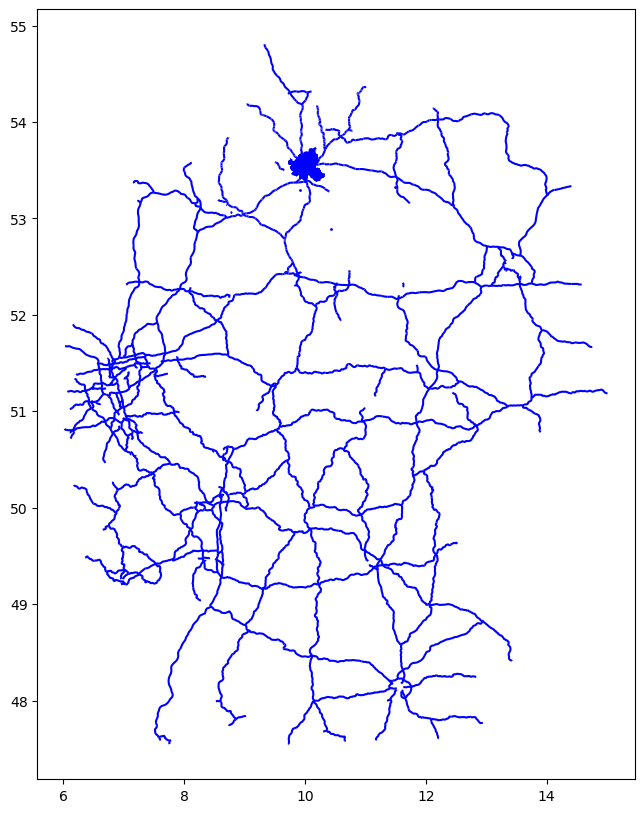

In [23]:
import matplotlib.pyplot as plt

district = districts[districts['id'] == 'APP_LANDESGRENZE_421']  # Barmbek-Süd
fig, ax = plt.subplots(figsize=(10,10))
gdf_all.plot(ax=ax, color='blue', markersize=1)
district.plot(ax=ax, color='red', alpha=0.3)
plt.show()

In [24]:
print(len(district))
print(district.geometry)

0
GeoSeries([], Name: geometry, dtype: geometry)


District GeoDataFrame ist leer, kann nicht geplottet werden.


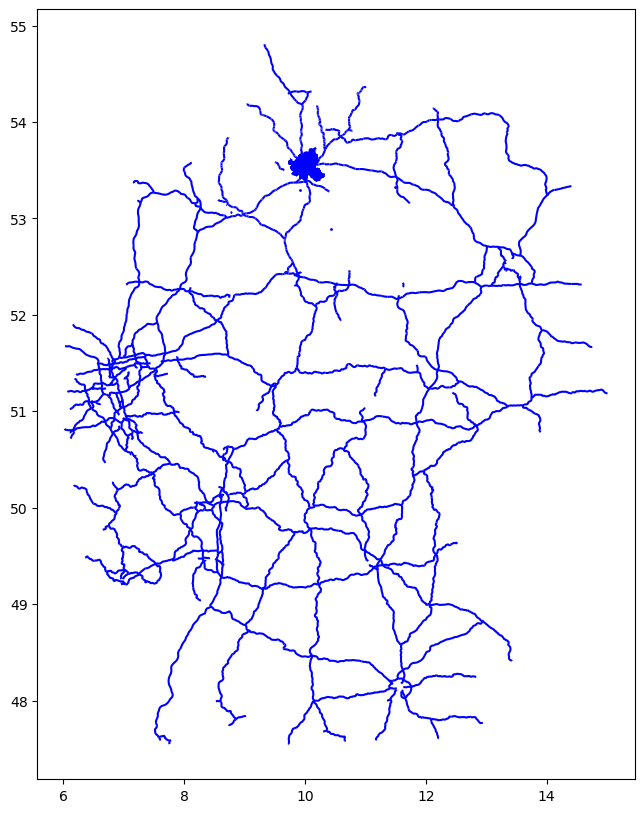

In [25]:
fig, ax = plt.subplots(figsize=(10,10))
gdf_all.plot(ax=ax, color='blue', markersize=1)

if len(district) > 0:
    district.plot(ax=ax, color='red', alpha=0.3)
else:
    print("District GeoDataFrame ist leer, kann nicht geplottet werden.")

plt.show()

In [26]:
print(len(district))                 # wie viele Polygone?
print(district.geometry.is_valid)    # sind die Geometrien gültig?
print(district.geometry.is_empty)    # sind sie leer?
print(district.total_bounds)         # Bounding Box

0
Series([], dtype: bool)
Series([], dtype: bool)
[nan nan nan nan]


In [27]:
lat_min, lat_max = 53.56, 53.59
lon_min, lon_max = 10.02, 10.06

In [28]:
# Mittelpunkt der Geometrien nehmen (für Linien/Polygone)
gdf_all['centroid'] = gdf_all.geometry.centroid

gdf_all['lon'] = gdf_all.centroid.x
gdf_all['lat'] = gdf_all.centroid.y

# Filter
df_barmbek = gdf_all[
    (gdf_all['lat'] >= lat_min) &
    (gdf_all['lat'] <= lat_max) &
    (gdf_all['lon'] >= lon_min) &
    (gdf_all['lon'] <= lon_max)
]

print(f"Zeilen in Barmbek-Süd (Bounding Box): {len(df_barmbek)}")

Zeilen in Barmbek-Süd (Bounding Box): 1762


/var/folders/44/4bwz988s0nz2kzlgp5nnzdl80000gn/T/ipykernel_76574/3984348389.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_all['centroid'] = gdf_all.geometry.centroid
/var/folders/44/4bwz988s0nz2kzlgp5nnzdl80000gn/T/ipykernel_76574/3984348389.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_all['lon'] = gdf_all.centroid.x
/var/folders/44/4bwz988s0nz2kzlgp5nnzdl80000gn/T/ipykernel_76574/3984348389.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_all['lat'] = gdf_all.centroid.y


In [29]:
print(df_barmbek.columns)
print(df_barmbek.head())
print(df_barmbek['wegeart'].value_counts())

Index(['_fid', 'bez', 'mark', 'id', 'lwt', 'lwe', 'lwn', 'lwst', 'lwse',
       'lwsn',
       ...
       'bezirk', 'hausnummer', 'strasse', 'knoten', 'art', 'LSA_Name',
       'geometry', 'centroid', 'lon', 'lat'],
      dtype='object', length=173)
                             _fid   bez  mark    id   lwt   lwe   lwn  lwst  \
72   DE.HH.UP_BUSFAHRSTREIFEN_105  None  None  None  None  None  None  None   
123  DE.HH.UP_BUSFAHRSTREIFEN_106  None  None  None  None  None  None  None   
124  DE.HH.UP_BUSFAHRSTREIFEN_107  None  None  None  None  None  None  None   
125  DE.HH.UP_BUSFAHRSTREIFEN_108  None  None  None  None  None  None  None   
126  DE.HH.UP_BUSFAHRSTREIFEN_109  None  None  None  None  None  None  None   

     lwse  lwsn  ... bezirk hausnummer strasse knoten   art LSA_Name  \
72   None  None  ...   None       None    None    NaN  None     None   
123  None  None  ...   None       None    None    NaN  None     None   
124  None  None  ...   None       None    None    NaN  None

In [30]:
df_city = df_barmbek[df_barmbek['wegeart'].str.contains("Stadtstraße", na=False)]

In [31]:
# In metrisches CRS umwandeln (Deutschland: EPSG:25832)
gdf_proj = gdf_all.to_crs("EPSG:25832")

# Zentroid berechnen
gdf_proj['centroid'] = gdf_proj.geometry.centroid

# Zurück nach WGS84 für lat/lon
gdf_all['centroid'] = gdf_proj['centroid'].to_crs("EPSG:4326")

gdf_all['lon'] = gdf_all.centroid.x
gdf_all['lat'] = gdf_all.centroid.y

/var/folders/44/4bwz988s0nz2kzlgp5nnzdl80000gn/T/ipykernel_76574/1604071193.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_all['lon'] = gdf_all.centroid.x
/var/folders/44/4bwz988s0nz2kzlgp5nnzdl80000gn/T/ipykernel_76574/1604071193.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_all['lat'] = gdf_all.centroid.y


In [32]:
print(df_barmbek['wegeart'].value_counts())

wegeart
Stadtstraße (alle Straßen, die nicht BAB oder Bundesstraßen sind, sowie zu einer anderen Wegeart gehören)    1366
Bundesstraße - Ortsdurchfahrt                                                                                  77
Stadtstraße                                                                                                    15
Sonstige Straße (Straßen mit eingeschränkter Funktion gem. Widmung)                                            14
unbekannt                                                                                                       2
Kommunaltrasse (Busse und Taxen)                                                                                1
Name: count, dtype: int64


In [33]:
# 2. Erste Walkability-Idee: Straßendichte
street_count = len(df_barmbek)
print(f"Anzahl Straßen/Objekte: {street_count}")

Anzahl Straßen/Objekte: 1762


In [34]:
# 3. Nur relevante Straßen
df_streets = df_barmbek[
    df_barmbek['wegeart'].str.contains("Stadtstraße", na=False)
]

print(len(df_streets))

1381


In [35]:
df_streets = df_barmbek[
    df_barmbek['wegeart'].str.contains("Stadtstraße", na=False)
]

print(f"Anzahl Stadtstraßen: {len(df_streets)}")

Anzahl Stadtstraßen: 1381


In [36]:
# in metrisches CRS umwandeln
df_proj = df_barmbek.to_crs("EPSG:25832")

# Gesamtfläche berechnen (in m²)
area_m2 = df_proj.geometry.area.sum()

# in km² umrechnen
area_km2 = area_m2 / 1_000_000

print(f"Fläche: {area_km2:.2f} km²")

Fläche: 85.41 km²


In [37]:
street_density = len(df_streets) / area_km2

print(f"Straßendichte: {street_density:.2f} Straßen pro km²")

Straßendichte: 16.17 Straßen pro km²


In [38]:
df_barmbek = df_barmbek.copy()

df_barmbek['weight'] = df_barmbek['wegeart'].apply(
    lambda x: 1 if isinstance(x, str) and "Stadtstraße" in x else 0.5
)

In [39]:
df_barmbek = df_barmbek.copy()

df_barmbek['weight'] = df_barmbek['wegeart'].apply(
    lambda x: 1 if isinstance(x, str) and "Stadtstraße" in x else 0.5
)

weighted_density = df_barmbek['weight'].sum() / area_km2

print(f"Weighted Density: {weighted_density:.2f}")

Weighted Density: 18.40


In [40]:
df_barmbek.loc[:, 'weight'] = df_barmbek['wegeart'].apply(
    lambda x: 1 if isinstance(x, str) and "Stadtstraße" in x else 0.5
)

In [41]:
df_barmbek.head()

,_fid,bez,mark,id,lwt,lwe,lwn,lwst,lwse,lwsn,...,hausnummer,strasse,knoten,art,LSA_Name,geometry,centroid,lon,lat,weight
72,DE.HH.UP_BUSFAHRSTREIFEN_105,None,None,None,None,None,None,None,None,None,...,None,None,NaN,None,None,"LINESTRING (10.04624 53.58757, 10.0462 53.5875...",POINT (10.04619 53.58755),10.046194,53.587548,1.0
123,DE.HH.UP_BUSFAHRSTREIFEN_106,None,None,None,None,None,None,None,None,None,...,None,None,NaN,None,None,"LINESTRING (10.04629 53.5874, 10.04632 53.5874...",POINT (10.04634 53.58742),10.046345,53.587422,1.0
124,DE.HH.UP_BUSFAHRSTREIFEN_107,None,None,None,None,None,None,None,None,None,...,None,None,NaN,None,None,"LINESTRING (10.04614 53.58749, 10.04614 53.587...",POINT (10.0462 53.58744),10.046201,53.587436,1.0
125,DE.HH.UP_BUSFAHRSTREIFEN_108,None,None,None,None,None,None,None,None,None,...,None,None,NaN,None,None,"LINESTRING (10.04637 53.58666, 10.04633 53.586...",POINT (10.04628 53.58664),10.046283,53.586639,1.0
126,DE.HH.UP_BUSFAHRSTREIFEN_109,None,None,None,None,None,None,None,None,None,...,None,None,NaN,None,None,"LINESTRING (10.04622 53.5866, 10.04621 53.5865...",POINT (10.04627 53.58654),10.046268,53.586535,1.0


In [45]:
df_barmbek_clean = df_barmbek.drop(columns=['centroid'], errors='ignore')

df_barmbek_clean.to_file(
    "../data/processed/barmbek_sued.geojson",
    driver="GeoJSON"
)

In [46]:
#Geojson anschauen und testen
import os
print(os.listdir("../data/processed/"))

['blindenzentrum_line.geojson', 'app_landesgrenze_EPSG_4326.json', 'hamburg_all.geojson', '.DS_Store', 'footways.geojson', 'bewohnerpark.geojson', 'barmbek_sued.geojson', 'ueberarbeitet_Stadtteilprofile Barmbek_Sued-Berichtsjahre-2013-2023.xlsx']


In [48]:
import geopandas as gpd

gdf_test = gpd.read_file("../data/processed/barmbek_sued.geojson")

print(gdf_test.shape)
print(gdf_test.head())

(1762, 173)
                           _fid   bez  mark    id   lwt   lwe   lwn  lwst  \
0  DE.HH.UP_BUSFAHRSTREIFEN_105  None  None  None  None  None  None  None   
1  DE.HH.UP_BUSFAHRSTREIFEN_106  None  None  None  None  None  None  None   
2  DE.HH.UP_BUSFAHRSTREIFEN_107  None  None  None  None  None  None  None   
3  DE.HH.UP_BUSFAHRSTREIFEN_108  None  None  None  None  None  None  None   
4  DE.HH.UP_BUSFAHRSTREIFEN_109  None  None  None  None  None  None  None   

   lwse  lwsn  ... bezirk hausnummer strasse knoten   art LSA_Name        lon  \
0  None  None  ...   None       None    None    NaN  None     None  10.046194   
1  None  None  ...   None       None    None    NaN  None     None  10.046345   
2  None  None  ...   None       None    None    NaN  None     None  10.046201   
3  None  None  ...   None       None    None    NaN  None     None  10.046283   
4  None  None  ...   None       None    None    NaN  None     None  10.046268   

         lat weight                   

# Vorhandene Daten prüfen

In [49]:
print(df_barmbek.columns.tolist())

['_fid', 'bez', 'mark', 'id', 'lwt', 'lwe', 'lwn', 'lwst', 'lwse', 'lwsn', 'lwtyp', 'lw_li', 'norm_a', 'kt', 'ke', 'kn', 'rw', 'flaeche', 'dmp', 'teinwt', 'teinwr', 'teinwn', 'k0', 'freq', 'richtw', 'pq_anzt', 'pq_anze', 'pq_anzn', 'geom', 'coordinate_reference_system', 'nr', 'ruhiges_gebiet', 'wnr_strassenname', 'rlagevst_beschreib', 'vst', 'bst', 'breite', 'leange', 'taxi', 'radfahrer', 'kommunaltrasse', 'wegeart', 'einrichtdat', 'bemerkung', 'vnk', 'nnk', 'von_netzknoten', 'nach_netzknoten', 'von_station', 'bis_station', 'von_km', 'bis_km', 'klasse', 'strassenschluessel', 'wegenummer', 'strassenname', 'landesschluessel', 'kreisschluessel', 'gemeindeschluessel', 'abschnittslaenge', 'ast', 'europastrasse', 'fahrstreifenanzahl_in_stationierungsrichtung', 'fahrstreifenanzahl_in_beide_richtungen', 'fahrstreifenanzahl_gegen_stationierungsrichtung', 'bahnigkeit', 'geschwindigkeit', 'gml_identifier', 'gml_identifier_attr_codespace', 'titel', 'organisation', 'anlass', 'umfang', 'baubeginn', 

In [50]:
df_barmbek[['wegeart', 'strasse', 'art']].head()

,wegeart,strasse,art
72,Stadtstraße,None,None
123,Stadtstraße,None,None
124,Stadtstraße,None,None
125,Stadtstraße,None,None
126,Stadtstraße,None,None


In [51]:
for name, df in dfs.items():
    print(f"\n--- {name} ---")
    print(df.shape)
    print(df.columns.tolist())


--- de_hh_up_nsz_area_EPSG_4326 ---
(1, 30)
['_fid', 'bez', 'mark', 'id', 'lwt', 'lwe', 'lwn', 'lwst', 'lwse', 'lwsn', 'lwtyp', 'lw_li', 'norm_a', 'kt', 'ke', 'kn', 'rw', 'flaeche', 'dmp', 'teinwt', 'teinwr', 'teinwn', 'k0', 'freq', 'richtw', 'pq_anzt', 'pq_anze', 'pq_anzn', 'geom', 'coordinate_reference_system']

--- de_hh_up_ruhige_gebiete_hamburg_EPSG_4326 ---
(15, 5)
['_fid', 'nr', 'ruhiges_gebiet', 'geom', 'coordinate_reference_system']

--- de_hh_up_busfahrstreifen_EPSG_4326 ---
(412, 17)
['_fid', 'wnr_strassenname', 'rlagevst_beschreib', 'vst', 'bst', 'breite', 'leange', 'taxi', 'radfahrer', 'kommunaltrasse', 'wegeart', 'einrichtdat', 'bemerkung', 'vnk', 'nnk', 'geom', 'coordinate_reference_system']

--- de_hh_up_bundesstrassen_ortsdurchfahrt_EPSG_4326 ---
(499, 25)
['_fid', 'von_netzknoten', 'nach_netzknoten', 'von_station', 'bis_station', 'von_km', 'bis_km', 'klasse', 'strassenschluessel', 'wegenummer', 'strassenname', 'landesschluessel', 'kreisschluessel', 'gemeindeschluesse

In [52]:
df_streets = df_barmbek[df_barmbek['wegeart'].notna()]

In [53]:
df_crossings = df_barmbek[df_barmbek['strassenname'].notna()]

In [54]:
df_lsa = df_barmbek[df_barmbek['LSA_Name'].notna()]

In [56]:
gdf_green = gpd.read_file("../data/raw/raw_data_geoportal_gruenflaechen/de_hh_up_gesamtstaedtische_gruenverbindung_EPSG_4326.json")
gdf_speed = gpd.read_file("../data/raw/raw_data_geoportal_gruenflaechen/de_hh_up_bundesstrassen_ortsdurchfahrt_EPSG_4326.csv")
gdf_parks = gpd.read_file("../data/raw/raw_data_geoportal_gruenflaechen/Digitaler_Gruenplan_HH-2015-07-07.gml")
gdf_switch = gpd.read_file("../data/raw/de_hh_up_switch_punkte_api_EPSG_4326.json")

In [58]:
type(gdf_speed)

pandas.core.frame.DataFrame

In [59]:
gdf_speed.head()

,_fid,von_netzknoten,nach_netzknoten,von_station,bis_station,von_km,bis_km,klasse,strassenschluessel,wegenummer,...,ast,europastrasse,fahrstreifenanzahl_in_stationierungsrichtung,fahrstreifenanzahl_in_beide_richtungen,fahrstreifenanzahl_gegen_stationierungsrichtung,bahnigkeit,geschwindigkeit,wegeart,geom,coordinate_reference_system
0,DE.HH.UP_BUNDESSTRASSEN_ORTSDURCHFAHRT_201213,252400004,252400018,0,837,,,G,,10357,...,0,,2,0,2,1,,Bundesstraße - Ortsdurchfahrt,"LINESTRING (9.795657 53.462750,9.806642 53.466...",EPSG:4326
1,DE.HH.UP_BUNDESSTRASSEN_ORTSDURCHFAHRT_201214,252400032,252400004,504,1498,,,G,,10357,...,0,,1,0,1,1,,Bundesstraße - Ortsdurchfahrt,"LINESTRING (9.779355 53.457224,9.792401 53.461...",EPSG:4326
2,DE.HH.UP_BUNDESSTRASSEN_ORTSDURCHFAHRT_201215,252400032,252400004,1498,1746,,,G,,10357,...,0,,2,0,2,1,,Bundesstraße - Ortsdurchfahrt,"LINESTRING (9.792401 53.461646,9.795657 53.462...",EPSG:4326
3,DE.HH.UP_BUNDESSTRASSEN_ORTSDURCHFAHRT_201216,242600109,242600071,0,216,,,B,,4 (7916),...,0,,0,0,2,1,50 km/h,Bundesstraße - Ortsdurchfahrt,"LINESTRING (10.007306 53.547818,10.006930 53.5...",EPSG:4326
4,DE.HH.UP_BUNDESSTRASSEN_ORTSDURCHFAHRT_201217,242600299,242600071,0,217,,,B,,4 (7916),...,0,,2,0,0,1,50 km/h,Bundesstraße - Ortsdurchfahrt,"LINESTRING (10.007307 53.547954,10.007106 53.5...",EPSG:4326


In [60]:
from shapely import wkt
import geopandas as gpd

gdf_speed['geometry'] = gdf_speed['geom'].apply(wkt.loads)

gdf_speed = gpd.GeoDataFrame(
    gdf_speed,
    geometry='geometry',
    crs="EPSG:4326"
)

In [61]:
def filter_barmbek(gdf):
    return gpd.sjoin(gdf, districts, predicate="intersects")

gdf_speed_b = filter_barmbek(gdf_speed)
gdf_green_b = filter_barmbek(gdf_green)
gdf_parks_b = filter_barmbek(gdf_parks)
gdf_switch_b = filter_barmbek(gdf_switch)

/var/folders/44/4bwz988s0nz2kzlgp5nnzdl80000gn/T/ipykernel_76574/2700361155.py:2: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:25832
Right CRS: EPSG:4326

  return gpd.sjoin(gdf, districts, predicate="intersects")


In [62]:
# districts in metrisches CRS bringen
districts = districts.to_crs("EPSG:25832")

# dann nochmal join
gdf_speed_b = gpd.sjoin(gdf_speed, districts, predicate="intersects")

/var/folders/44/4bwz988s0nz2kzlgp5nnzdl80000gn/T/ipykernel_76574/47212043.py:5: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:25832

  gdf_speed_b = gpd.sjoin(gdf_speed, districts, predicate="intersects")


In [63]:
def filter_barmbek(gdf, districts):
    # CRS angleichen
    gdf = gdf.to_crs("EPSG:25832")
    districts = districts.to_crs("EPSG:25832")
    
    return gpd.sjoin(gdf, districts, predicate="intersects")

In [64]:
print(gdf_speed_b.shape)
print(gdf_green_b.shape)
print(gdf_parks_b.shape)

(0, 29)
(57, 7)
(0, 24)


In [65]:
print(districts.shape)
print(districts.columns)

(1, 3)
Index(['id', 'fhh', 'geometry'], dtype='object')


In [71]:
from shapely.geometry import Polygon

coords = [
    (10.02, 53.56),
    (10.06, 53.56),
    (10.06, 53.59),
    (10.02, 53.59)
]

barmbek_poly = gpd.GeoDataFrame(
    geometry=[Polygon(coords)],
    crs="EPSG:4326"
)

In [72]:
gdf_barmbek_sued = gpd.sjoin(gdf, barmbek_poly, predicate="intersects")

In [73]:
gdf_barmbek_sued.head()

,_fid,knoten,art,LSA_Name,geom,coordinate_reference_system,geometry,index_right
32,APP_LSA_KNOTENGRUNDDATEN_15699,51,K-LSA,Winterhuder Weg/Hamburger Straße,MULTIPOINT (10.027019 53.570270),EPSG:4326,MULTIPOINT ((10.02702 53.57027)),0
51,APP_LSA_KNOTENGRUNDDATEN_15718,81,K-LSA,Dehnhaide/Friedrichsberger Straße,MULTIPOINT (10.048979 53.578666),EPSG:4326,MULTIPOINT ((10.04898 53.57867)),0
67,APP_LSA_KNOTENGRUNDDATEN_15734,101,K-LSA,Hamburger Straße/Wagnerstraße,MULTIPOINT (10.035324 53.574978),EPSG:4326,MULTIPOINT ((10.03532 53.57498)),0
84,APP_LSA_KNOTENGRUNDDATEN_15751,125,K-LSA,Bramfelder Straße/Fuhlsbüttler Straße,MULTIPOINT (10.047330 53.584074),EPSG:4326,MULTIPOINT ((10.04733 53.58407)),0
87,APP_LSA_KNOTENGRUNDDATEN_15754,129,K-LSA,Lübecker Straße/Landwehr,MULTIPOINT (10.034410 53.564131),EPSG:4326,MULTIPOINT ((10.03441 53.56413)),0


In [75]:
num_lsa = len(gdf_barmbek_sued)
print("Anzahl Ampeln:", num_lsa)

Anzahl Ampeln: 94


In [76]:
print(type(barmbek_poly))
print(barmbek_poly.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
EPSG:4326


In [77]:
import geopandas as gpd

def filter_to_barmbek(gdf, boundary):
    # CRS angleichen
    gdf = gdf.to_crs(boundary.crs)
    
    # Spatial Join
    gdf_b = gpd.sjoin(gdf, boundary, predicate="intersects")
    
    # Aufräumen
    if 'index_right' in gdf_b.columns:
        gdf_b = gdf_b.drop(columns=['index_right'])
    
    return gdf_b

In [80]:
gdf_lsa_b = filter_to_barmbek(df_lsa, barmbek_poly)
print(len(gdf_lsa_b))

94


In [81]:
gdf_crossings_b = filter_to_barmbek(gdf_crossings, barmbek_poly)

NameError: name 'gdf_crossings' is not defined

In [ ]:
gdf_parks_b = filter_to_barmbek(gdf_parks, barmbek_poly)